# Test von Max

## 2. Data
*Instructions: Describe the dataset, its source, and why it was chosen. Detail the preprocessing steps.*

**Dataset Source:** PUMS (Public Use Microdata Sample) from the US Census Bureau.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import logging
from datetime import datetime
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import joblib

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger()

# Define Paths
DATA_RAW = '00 data/raw/psam_p38.csv'
DATA_PROCESSED = '00 data/processed'
OUTPUT_DIR = 'output'

os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

### 2.1 Data Understanding & Exploration

**Objectives:**
*   **Initial Analysis:** Inspect data shape, missing values, and data quality.
*   **Statistical Checks:** Analyze variance, correlation, and mutual information.
*   **Health Indicators:** Explore the distribution of health insurance coverage types and their combinations.
*   **Feature Distribution:** Visualize key demographic and economic features.

Loading raw data...
Data Shape: 4,701 rows, 287 columns


,RT,SERIALNO,DIVISION,SPORDER,PUMA,REGION,STATE,ADJINC,PWGTP,AGEP,...,PWGTP71,PWGTP72,PWGTP73,PWGTP74,PWGTP75,PWGTP76,PWGTP77,PWGTP78,PWGTP79,PWGTP80
0,P,2023GQ0000978,4,1,600,2,38,1019518,5,41,...,7,6,5,5,7,7,4,4,5,5
1,P,2023GQ0001384,4,1,600,2,38,1019518,113,22,...,86,97,131,13,120,17,107,108,7,12
2,P,2023GQ0002487,4,1,600,2,38,1019518,129,21,...,129,229,113,12,243,256,10,139,136,12



--- Data Quality: Missing Values ---
Columns with Missing Values:
           Missing Count Percentage
ESP                 4701    100.00%
NOP                 4701    100.00%
GCM                 4678     99.51%
SFR                 4673     99.40%
SFN                 4673     99.40%
GCR                 4652     98.96%
CITWP               4629     98.47%
DRAT                4611     98.09%
FOD2P               4539     96.55%
FHINS5C             4498     95.68%
YOEP                4483     95.36%
DECADE              4483     95.36%
FHINS3C             4445     94.55%
ENG                 4439     94.43%
LANP                4439     94.43%
MLPE                4407     93.75%
MLPJ                4407     93.75%
MLPIK               4407     93.75%
MLPFG               4407     93.75%
MLPH                4407     93.75%
MLPCD               4407     93.75%
MLPB                4407     93.75%
MLPA                4407     93.75%
VPS                 4407     93.75%
DRATX               4343     92.3

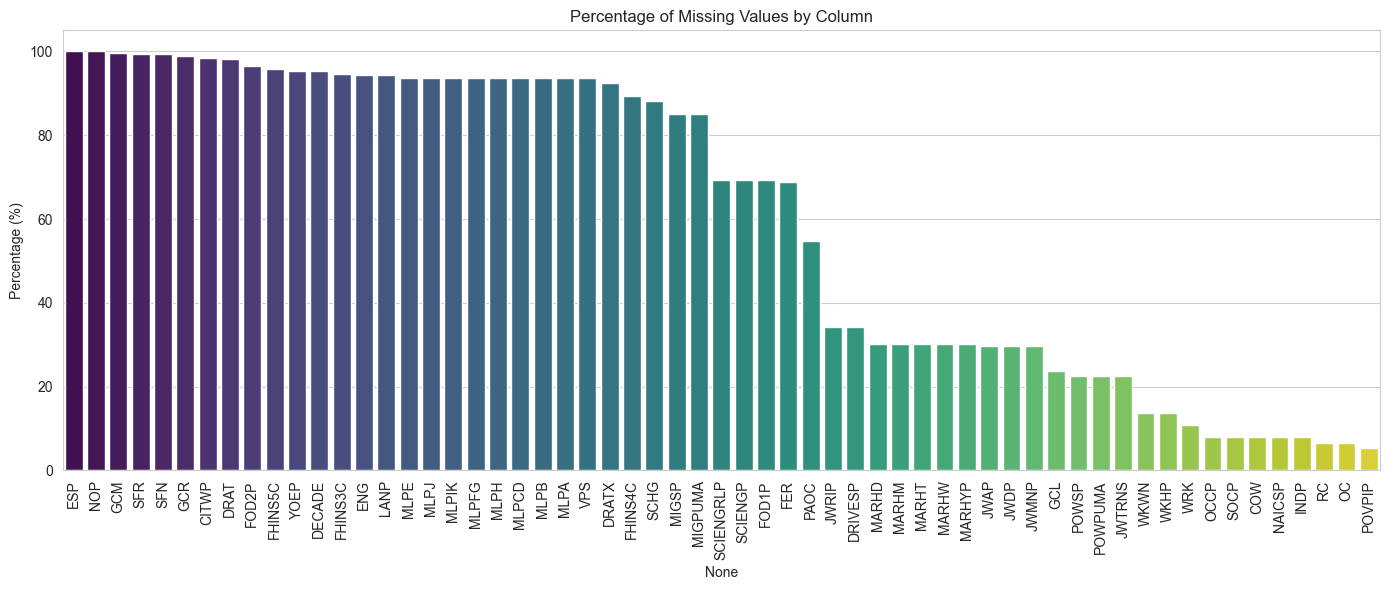

Age Range: 18 - 65

--- Statistical Analysis ---
Features with near-zero variance (<0.1): 87
Columns with near-zero variance:
DIVISION     0.000000
MLPH         0.000000
MLPFG        0.000000
OC           0.000000
RC           0.000000
SFN          0.000000
FANCP        0.000000
MLPIK        0.000000
MLPJ         0.000000
REGION       0.000000
STATE        0.000000
FSEXP        0.000000
ADJINC       0.000000
FDRATP       0.000425
FGCLP        0.000425
FGCMP        0.000425
RACNH        0.000638
RACPI        0.001063
FGCRP        0.001487
MARHW        0.001522
FCITWP       0.002335
FRELSHIPP    0.003393
MLPE         0.003401
FDRATXP      0.005501
FWRKP        0.005712
FENGP        0.006342
FYOEP        0.007810
FHISP        0.008647
FAGEP        0.008856
FMILPP       0.008856
FHINS5C      0.009803
FLANP        0.009900
MARHD        0.009957
FHINS3C      0.011627
GCL          0.013485
FSCHGP       0.014052
DDRS         0.017553
FRACP        0.017553
DEYE         0.020008
RACASN       0.0

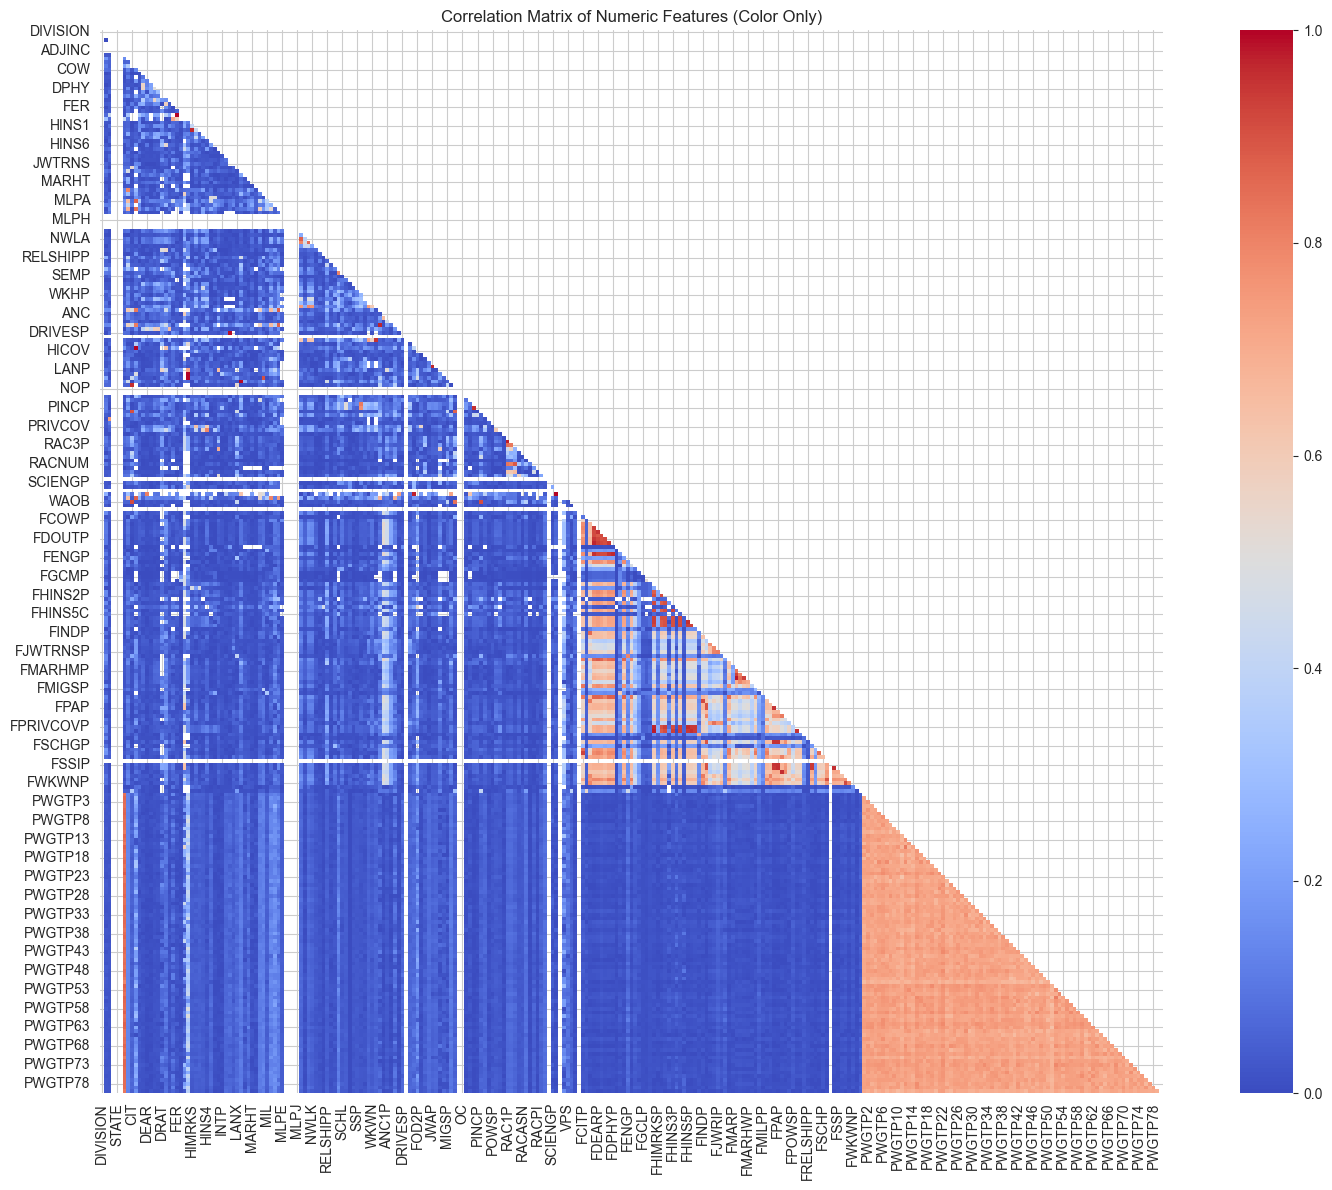


--- Mutual Information Analysis ---
Top 10 Features by Mutual Information:
PUBCOV     0.238849
PRIVCOV    0.135961
POVPIP     0.075173
HINS1      0.074468
PINCP      0.060967
PERNP      0.059206
OCCP       0.057615
WAGP       0.052264
WKWN       0.052031
JWDP       0.046980
dtype: float64


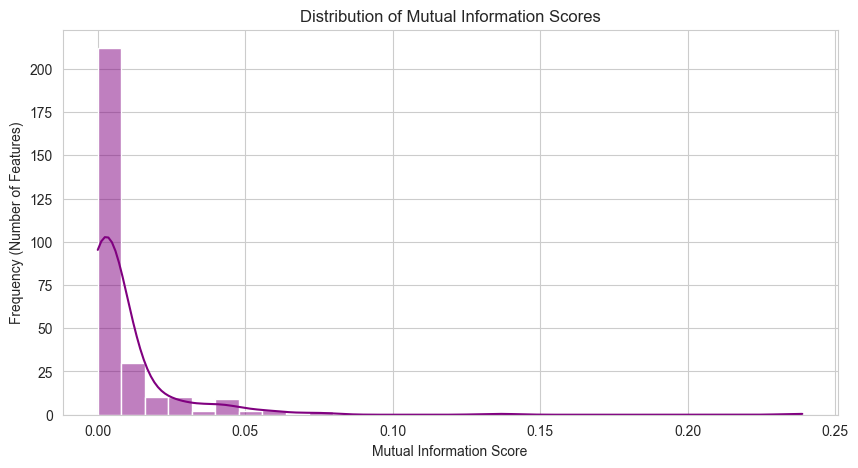


--- Health Indicators ---
Class Imbalance (HINS4 - Medicaid):
HINS4
No     0.893427
Yes    0.106573
Name: proportion, dtype: float64


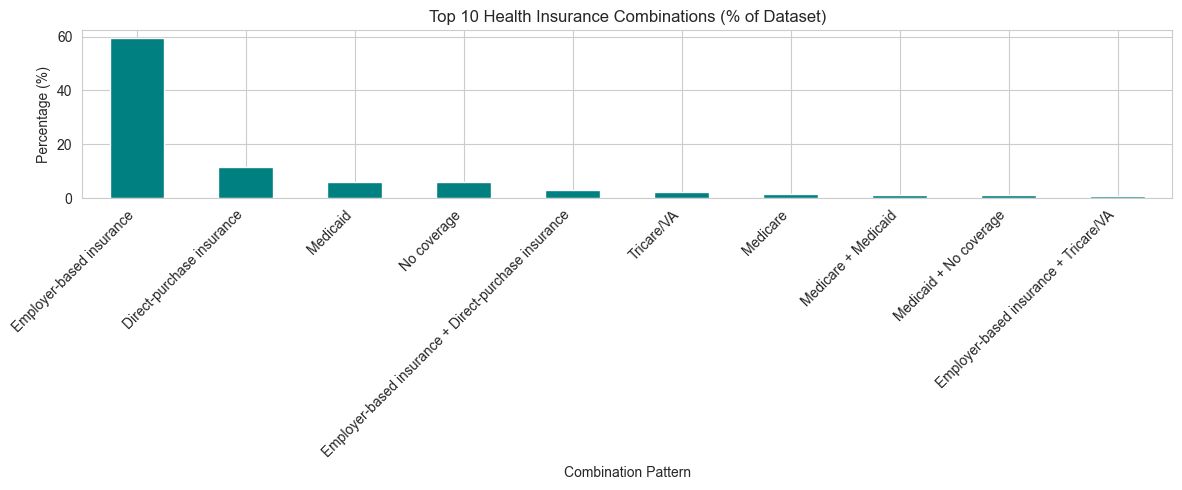

In [2]:
# Load Data
if os.path.exists(DATA_RAW):
    print("Loading raw data...")
    df_raw = pd.read_csv(DATA_RAW)
    df_raw = df_raw[(df_raw['AGEP'] >= 18) & (df_raw['AGEP'] <= 65)] # Filter Age
    # 1. Head & Shape
    print(f"Data Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
    display(df_raw.head(3))

    # 2. Data Quality Check (Missing Values)
    print("\n--- Data Quality: Missing Values ---")
    missing = df_raw.isnull().sum()
    missing = missing[missing > 0]

    if not missing.empty:
        missing_pct = (missing / len(df_raw)) * 100
        missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})

        # Sort by percentage descending
        missing_df = missing_df.sort_values('Percentage', ascending=False)

        # List with column and percentage
        print("Columns with Missing Values:")
        print(missing_df.to_string(formatters={'Percentage': '{:,.2f}%'.format}))

        # Chart: Distribution of columns with missing values (ordered by percentage)
        plt.figure(figsize=(14, 6))
        sns.barplot(x=missing_df.index, y=missing_df['Percentage'], palette='viridis', order=missing_df.index)
        plt.title('Percentage of Missing Values by Column')
        plt.ylabel('Percentage (%)')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
    else:
        print("No missing values found.")

    print(f"Age Range: {df_raw['AGEP'].min()} - {df_raw['AGEP'].max()}")

    # 3. Statistical Analysis
    print("\n--- Statistical Analysis ---")
    numeric_cols = df_raw.select_dtypes(include=[np.number]).columns

    # Near-zero variance features
    variances = df_raw[numeric_cols].var()
    zero_var_cols = variances[variances < 0.1]
    if not zero_var_cols.empty:
        print(f"Features with near-zero variance (<0.1): {len(zero_var_cols)}")
        print("Columns with near-zero variance:")
        print(zero_var_cols.sort_values().to_string())
    else:
        print("No features with near-zero variance found.")

    # 4. Correlation Analysis
    print("\n--- Correlation Analysis ---")
    corr_matrix = df_raw[numeric_cols].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr = [column for column in upper.columns if any(upper[column] > 0.95)]
    print(f"Highly Correlated Features (>0.95): {len(high_corr)} features")

    # Correlation Matrix Heatmap (without numeric values)
    plt.figure(figsize=(16, 12))
    sns.heatmap(corr_matrix,
                annot=False,  # Remove numeric annotations
                fmt=".2f",
                cmap='coolwarm',
                mask=np.triu(np.ones_like(corr_matrix, dtype=bool)),
                cbar=True,
                square=True)
    plt.title('Correlation Matrix of Numeric Features (Color Only)')
    plt.tight_layout()
    plt.show()

    # Mutual Information
    if 'HINS4' in df_raw.columns:
        print("\n--- Mutual Information Analysis ---")
        # Sample for speed
        sample_df = df_raw.sample(min(5000, len(df_raw)), random_state=42).fillna(0)
        X_mi = sample_df.select_dtypes(include=[np.number]).drop(columns=['HINS4'], errors='ignore')
        y_mi = sample_df['HINS4']

        mi = mutual_info_classif(X_mi, y_mi, random_state=42)
        mi_series = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)

        print("Top 10 Features by Mutual Information:")
        print(mi_series.head(10))
        # Distribution of Mutual Information
        plt.figure(figsize=(10, 5))
        sns.histplot(mi_series, bins=30, kde=True, color='purple')
        plt.title('Distribution of Mutual Information Scores')
        plt.xlabel('Mutual Information Score')
        plt.ylabel('Frequency (Number of Features)')
        plt.show()

    # 5. Health Indicators & Class Imbalance
    print("\n--- Health Indicators ---")

    # Define HINS labels
    hins_labels = {
        'HINS1': 'Employer-based insurance',
        'HINS2': 'Direct-purchase insurance',
        'HINS3': 'Medicare',
        'HINS4': 'Medicaid',
        'HINS5': 'Tricare/VA',
        'HINS6': 'Other public insurance',
        'HINS7': 'No coverage'
    }

    if 'HINS4' in df_raw.columns:
        # Replace 1/2 with descriptive labels for display
        dist = df_raw['HINS4'].map({1: 'Yes', 2: 'No'}).value_counts(normalize=True)
        print(f"Class Imbalance (HINS4 - {hins_labels['HINS4']}):")
        print(dist)

    # HINS Combinations Chart with labels and percentages
    hins_cols = sorted([c for c in df_raw.columns if c.startswith('HINS') and len(c) == 5])
    if hins_cols:
        # Create a mapping function for the combination labels
        def map_hins_combo(row):
            combo_parts = []
            for col in hins_cols:
                val = row[col]
                if val == 1:
                    combo_parts.append(hins_labels.get(col, col))
            return ' + '.join(combo_parts) if combo_parts else 'No coverage'

        df_raw['HINS_Combo_Label'] = df_raw.apply(map_hins_combo, axis=1)
        top_combos = df_raw['HINS_Combo_Label'].value_counts(normalize=True).head(10) * 100  # Convert to percentage

        plt.figure(figsize=(12, 5))
        top_combos.plot(kind='bar', color='teal')
        plt.title('Top 10 Health Insurance Combinations (% of Dataset)')
        plt.xlabel('Combination Pattern')
        plt.ylabel('Percentage (%)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
else:
    print(f"Data file not found at {DATA_RAW}")


## 3. Data Cleaning and Feature Engineering
In this section, we process the raw data through a structured pipeline involving attribute selection, data cleaning, and feature engineering.

### 3.1 Attribute Dropping
We filter the dataset to retain only the most relevant features for our analysis, grouped by domain. This step reduces dimensionality and focuses the model on impactful variables.

**Kept Features:**
*   **GROUP 1: Income & Affordability:** `WAGP`, `POVPIP`, `SEMP`, `INTP`, `RETP`, `SSP`, `SSIP`, `PAP`
*   **GROUP 2: Employment Quality:** `ESR`, `COW`, `WKL`, `OCCP_2digit`, `INDP_2digit`
*   **GROUP 3: Demographics & Life Stage:** `AGEP`, `SEX`, `MAR`, `MIG`, `NATIVITY`, `RAC1P`, `HISP`
*   **GROUP 4: Education:** `SCHL`, `SCH`
*   **GROUP 5: Health & Disability:** `DIS`, `DEAR`, `DEYE`, `DPHY`
*   **GROUP 6: Geography:** `STATE`, `PUMA`, `REGION`, `DIVISION`
*   **Target:** `only_medicaid` (defined in 3.3)

In [ ]:
def filter_attributes(df_input):
    print("3.1 Attribute Dropping...")
    df = df_input.copy()

    # 2. Define Feature Groups
    keep_cols = [
        # Target
        'HINS4', 'HINS1', 'HINS2', 'HINS3', 'HINS5', 'HINS6', 'HINS7',
        # Income & Affordability
        'WAGP', 'POVPIP', 'SEMP', 'INTP', 'RETP', 'SSP', 'SSIP', 'PAP',
        # Employment Quality
        'ESR', 'COW', 'WKL', 'OCCP', 'INDP',
        # Demographics
        'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP',
        # Education
        'SCHL', 'SCH',
        # Health
        'DIS', 'DEAR', 'DEYE', 'DPHY',
        # Geography
        'STATE', 'PUMA', 'REGION', 'DIVISION'
    ]
    
    # Filter columns
    existing_cols = [c for c in keep_cols if c in df.columns]
    dropped_cols = len(df.columns) - len(existing_cols)
    
    df_selected = df[existing_cols].copy()
    print(f"Retained {len(existing_cols)} features. Dropped {dropped_cols} features.")
    return df_selected

# Execute 3.1
if os.path.exists(DATA_RAW):
    print("Loading raw data...")
    df_raw = pd.read_csv(DATA_RAW)
    # Filter Age immediately
    df_raw = df_raw[(df_raw['AGEP'] >= 18) & (df_raw['AGEP'] <= 65)]
    
    df_3_1 = filter_attributes(df_raw)
    display(df_3_1.head(3))

Loading raw data...
3.1 Attribute Dropping...
Retained 37 features. Dropped 250 features.


,HINS4,HINS1,HINS2,HINS3,HINS5,HINS6,HINS7,WAGP,POVPIP,SEMP,...,SCHL,SCH,DIS,DEAR,DEYE,DPHY,STATE,PUMA,REGION,DIVISION
0,1,2,2,2,2,2,2,0.0,0.0,0.0,...,16.0,1.0,1,2,2,1.0,38,600,2,4
1,2,2,1,2,2,2,2,3000.0,NaN,0.0,...,19.0,2.0,2,2,2,2.0,38,600,2,4
2,2,1,1,2,2,2,2,5200.0,NaN,0.0,...,19.0,2.0,2,2,2,2.0,38,600,2,4


### 3.2 Data Cleaning
We perform a comprehensive data quality check and cleaning process.

**Steps:**
1.  **Duplicate Removal:** Identify and remove duplicate records to prevent bias.
2.  **Missing Value Analysis:** Calculate and visualize the extent of missing data.
3.  **Imputation:**
    *   **Numerical Features:** Imputed using the **Median** to be robust against outliers.
    *   **Categorical Features:** Imputed using the **Mode** (most frequent value).
    *   *Note:* For features with specific business logic (e.g., `ESR`, `WAGP`), we ensure imputation does not mask meaningful "Unknown" states required for Section 3.3.

3.2 Data Cleaning & Quality Check...
Removed 68 duplicate rows.

Found 4 columns with missing values.
        Missing Count  Percentage
COW               355    7.662422
OCCP              355    7.662422
INDP              355    7.662422
POVPIP            199    4.295273


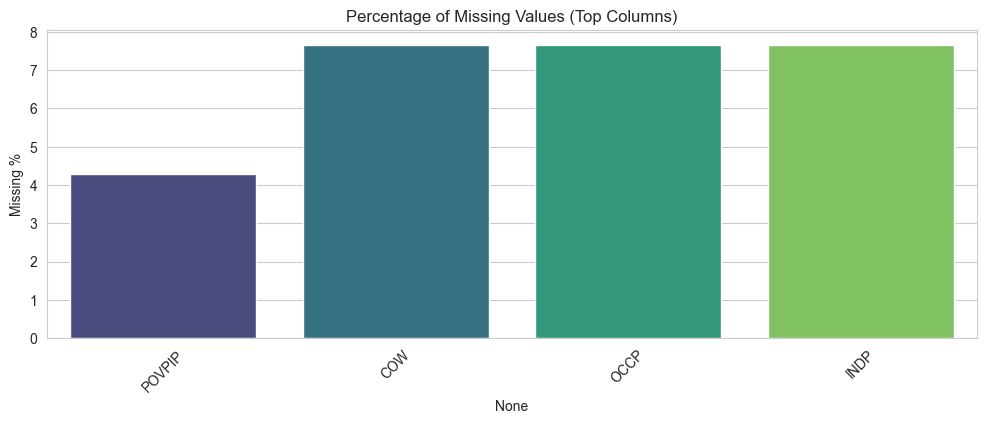


Applying Imputation...
 -> Imputed OCCP (Numeric) with Median: 4110.0
 -> Imputed INDP (Numeric) with Median: 6992.0
Data Cleaning Completed.
Shape after cleaning: (4633, 37)


In [7]:
def clean_data(df_input):
    print("3.2 Data Cleaning & Quality Check...")
    df = df_input.copy()

    # 1. Duplicate Check
    initial_rows = len(df)
    df = df.drop_duplicates()
    dropped_rows = initial_rows - len(df)
    if dropped_rows > 0:
        print(f"Removed {dropped_rows} duplicate rows.")
    else:
        print("No duplicate rows found.")

    # 2. Missing Value Analysis
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    
    if not missing.empty:
        print(f"\nFound {len(missing)} columns with missing values.")
        missing_pct = (missing / len(df)) * 100
        missing_report = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
        print(missing_report.sort_values('Percentage', ascending=False).head(10))
        
        # Visualization
        plt.figure(figsize=(12, 4))
        sns.barplot(x=missing_pct.index, y=missing_pct.values, palette='viridis')
        plt.title('Percentage of Missing Values (Top Columns)')
        plt.ylabel('Missing %')
        plt.xticks(rotation=45)
        plt.show()
    else:
        print("\nNo missing values found.")

    # 3. Imputation
    # We use a selective approach:
    # - Generic columns: Impute with Median/Mode.
    # - Key Business Columns (used in 3.3): We KEEP NaNs or fill with a placeholder to allow 3.3 logic to handle them (e.g. map to 'Unknown').
    
    # List of columns to SKIP generic imputation because 3.3 handles them specifically:
    # WAGP (Income), POVPIP (Poverty), ESR (Employment), COW (Worker Class), MAR (Marital), SCHL (Education)
    special_cols = ['WAGP', 'POVPIP', 'ESR', 'COW', 'MAR', 'SCHL', 'SCH', 'AGEP']
    
    print("\nApplying Imputation...")
    # Numeric
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if col not in special_cols and df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f" -> Imputed {col} (Numeric) with Median: {median_val}")

    # Categorical
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        if col not in special_cols and df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f" -> Imputed {col} (Categorical) with Mode: {mode_val}")

    print("Data Cleaning Completed.")
    return df

# Execute 3.2
if 'df_3_1' in locals():
    df_3_2 = clean_data(df_3_1)
    print(f"Shape after cleaning: {df_3_2.shape}")

### 3.3 New Data Frame
We create a new dataframe with engineered features based on business logic. This involves binning continuous variables (like Income and Age) and creating simplified categories for Employment and Education.

**Feature Engineering Logic:**
*   **Income:** Grouped wages (`income_group`), poverty bands (`poverty_band`), and income source counts.
*   **Employment:** Simplified employment status (`employment_status_simple`) and employer type (`employer_type`).
*   **Demographics:** Age groups (`age_group`) and simplified marital status (`marital_status_simple`).
*   **Education:** Simplified education levels (`education_level`) and enrollment status (`currently_enrolled`).
*   **Health:** Aggregated disability indicator (`has_any_disability`).

In [ ]:
def engineer_features(df_input):
    print("3.3 Engineering Features...")
    df = df_input.copy()
    
    # Create target variable 
    
    insurance = ["HINS1","HINS2","HINS3","HINS5","HINS6","HINS7"]

    df["target"] = np.where(
        (df["HINS4"] == 1) & df[insurance].eq(2).all(axis=1),
        1,
        0
    )
    df = df.drop(columns=[c for c in df.columns if c.startswith("HINS")])
    
    # 1. Create Derived Features needed for selection
    # OCCP/INDP 2-digit conversion

    if 'OCCP' in df.columns:
        df['OCCP_2digit'] = df['OCCP'].fillna(0).astype(int).astype(str).str.zfill(4).str[:2]
    if 'INDP' in df.columns:
        df['INDP_2digit'] = df['INDP'].fillna(0).astype(int).astype(str).str.zfill(4).str[:2]
        
    # Map ST to STATE if needed
    if 'ST' in df.columns and 'STATE' not in df.columns:
        df['STATE'] = df['ST']

    # --- GROUP 1: Income & Affordability ---
    # 1. income_group
    if 'WAGP' in df.columns:
        bins = [0, 15000, 30000, 50000, 75000, np.inf]
        labels = ['Very_Low', 'Low', 'Medium', 'High', 'Very_High']
        df['income_group'] = pd.cut(df['WAGP'], bins=bins, labels=labels)
        df.loc[df['WAGP'] <= 0, 'income_group'] = np.nan
    
    # 2. has_wage_income
    if 'WAGP' in df.columns:
        df['has_wage_income'] = (df['WAGP'] > 0).astype(int)
        
    # 3. income_source_count
    income_cols = ['WAGP','SEMP','INTP','RETP','SSP','SSIP','PAP']
    avail_inc_cols = [c for c in income_cols if c in df.columns]
    if avail_inc_cols:
        df['income_source_count'] = (df[avail_inc_cols] > 0).sum(axis=1)

    # 4. poverty_band
    if 'POVPIP' in df.columns:
        bins = [0, 100, 138, 200, 400, np.inf]
        labels = ['<100%', '100-138%', '138-200%', '200-400%', '>400%']
        df['poverty_band'] = pd.cut(df['POVPIP'], bins=bins, labels=labels)
        df.loc[df['POVPIP'] <= 0, 'poverty_band'] = np.nan

    # 5. has_self_employment
    if 'SEMP' in df.columns:
        df['has_self_employment'] = (df['SEMP'] > 0).astype(int)

    # --- GROUP 2: Employment Quality ---
    # 1. employment_status_simple
    if 'ESR' in df.columns:
        esr_mapping = {
            1: 'Employed', 2: 'Employed',
            3: 'Unemployed',
            4: 'Not_in_labor_force', 5: 'Not_in_labor_force', 6: 'Not_in_labor_force'
        }
        df['employment_status_simple'] = df['ESR'].map(esr_mapping).fillna('Not_in_labor_force')

    # 2. employer_type
    if 'COW' in df.columns:
        cow_mapping = {
            1: 'Private', 2: 'Private',
            3: 'Government', 4: 'Government', 5: 'Government',
            6: 'Self_employed', 7: 'Self_employed',
            8: 'Unpaid', 9: 'Unpaid'
        }
        df['employer_type'] = df['COW'].map(cow_mapping).fillna('Unknown')

    # --- GROUP 3: Demographics & Life Stage ---
    # 1. age_group
    if 'AGEP' in df.columns:
        bins = [17, 25, 35, 45, 55, 65]
        labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
        df['age_group'] = pd.cut(df['AGEP'], bins=bins, labels=labels)

    # 2. marital_status_simple
    if 'MAR' in df.columns:
        mar_mapping = {
            1: 'Married',
            2: 'Divorced_Separated', 3: 'Divorced_Separated', 4: 'Divorced_Separated',
            5: 'Never_married'
        }
        df['marital_status_simple'] = df['MAR'].map(mar_mapping).fillna('Unknown')

    # --- GROUP 4: Education ---
    # 1. education_level
    if 'SCHL' in df.columns:
        def map_education(val):
            if pd.isna(val) or val == 0: return 'Unknown'
            if val <= 15: return 'Less_than_HS'
            if val <= 17: return 'HS_diploma'
            if val <= 20: return 'Some_college'
            if val == 21: return 'Bachelors'
            return 'Graduate'
        df['education_level'] = df['SCHL'].apply(map_education)

    # 2. currently_enrolled
    if 'SCH' in df.columns:
        df['currently_enrolled'] = df['SCH'].isin([2, 3]).astype(int)

    # --- GROUP 5: Health & Disability ---
    # 1. has_any_disability
    dis_cols = ['DIS', 'DEAR', 'DEYE', 'DPHY']
    avail_dis_cols = [c for c in dis_cols if c in df.columns]
    if avail_dis_cols:
        df['has_any_disability'] = (df[avail_dis_cols] == 1).any(axis=1).astype(int)

    print("Feature Engineering Completed.")
    return df

# Execute 3.3
if 'df_3_2' in locals():
    df_3_3 = engineer_features(df_3_2)
    display(df_3_3.head(3))

3.3 Engineering Features...
Feature Engineering Completed.


,WAGP,POVPIP,SEMP,INTP,RETP,SSP,SSIP,PAP,ESR,COW,...,income_source_count,poverty_band,has_self_employment,employment_status_simple,employer_type,age_group,marital_status_simple,education_level,currently_enrolled,has_any_disability
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,NaN,...,0,NaN,0,Not_in_labor_force,Unknown,36-45,Divorced_Separated,HS_diploma,0,1
1,3000.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,6.0,3.0,...,1,NaN,0,Not_in_labor_force,Government,18-25,Never_married,Some_college,1,0
2,5200.0,NaN,0.0,-1100.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1,NaN,0,Employed,Private,18-25,Never_married,Some_college,1,0


### 3.4 Feature Sets for Modeling
We create 6 datasets with different feature sets for modeling to evaluate performance across different levels of data availability and complexity.

**Feature Sets:**
1.  **Statistical (Baseline):** Original features processed to remove low variance and highly correlated variables.
2.  **Realistic:** A subset of features that would realistically be available in a deployment scenario (e.g., demographics, basic employment info).
3.  **Business:** A richer feature set including domain-specific variables and potential cross-selling information.
4.  **PCA Statistical:** The Statistical set reduced using Principal Component Analysis (PCA).
5.  **PCA Realistic:** The Realistic set reduced using PCA.
6.  **PCA Business:** The Business set reduced using PCA.

**Pipeline for Each Set:**
*   Feature Selection
*   One-Hot Encoding (for categorical variables)
*   Standard Scaling
*   PCA Reduction
*   Randomization

In [9]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer

def create_feature_sets(df_input):
    print("3.4 Creating Feature Sets...")
    # We use df_3_3 (Engineered, Pre-Encoding) as the base to allow for specific feature selection
    df = df_input.copy()
    target = 'HINS4'
    
    if target not in df.columns:
        print(f"Error: Target {target} not found.")
        return {}

    # --- Define Column Lists ---
    
    # 1. Realistic Features
    cols_realistic = [
        'income_group', 'has_wage_income', 'has_self_employment',
        'employment_status_simple', 'employer_type',
        'SEX', 'age_group', 'marital_status_simple',
        'education_level', 'currently_enrolled',
        'STATE', 'PUMA', 'REGION', 'DIVISION'
    ]
    
    # 2. Business Features
    cols_business = [
        'WAGP', 'SEMP', 'income_group', 'income_source_count', 'has_wage_income', 'has_self_employment',
        'WKL', 'OCCP_2digit', 'INDP_2digit', 'employment_status_simple', 'employer_type',
        'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP', 'age_group', 'marital_status_simple',
        'education_level', 'currently_enrolled', 'has_any_disability',
        'STATE', 'PUMA', 'REGION', 'DIVISION'
    ]
    
    # 3. Statistical (Baseline) Features
    # Use all original columns from 3.1, excluding the new engineered ones from 3.3
    engineered_cols = [
        'income_group', 'has_wage_income', 'income_source_count', 'poverty_band', 
        'has_self_employment', 'employment_status_simple', 'employer_type', 
        'age_group', 'marital_status_simple', 'education_level', 'currently_enrolled', 
        'has_any_disability'
    ]
    cols_statistical = [c for c in df.columns if c not in engineered_cols and c != target]

    # --- Helper: Preprocessing (Encoding + Scaling) ---
    def preprocess_set(df_subset, col_list, set_name):
        # Filter columns that exist in the dataframe
        valid_cols = [c for c in col_list if c in df_subset.columns]
        missing_cols = set(col_list) - set(valid_cols)
        if missing_cols:
            print(f"  [{set_name}] Warning: Missing columns: {missing_cols}")
            
        X = df_subset[valid_cols].copy()
        y = df_subset[target]
        
        # Identify types
        cat_cols = X.select_dtypes(include=['object', 'category']).columns
        num_cols = X.select_dtypes(include=[np.number]).columns
        
        # Handle Missing Values (Critical for PCA/Scaling)
        # Numeric: Median
        if len(num_cols) > 0:
            imputer = SimpleImputer(strategy='median')
            X[num_cols] = imputer.fit_transform(X[num_cols])
            
        # Categorical: Fill with 'Unknown' before OHE to treat missing as a category
        for col in cat_cols:
            if isinstance(X[col].dtype, pd.CategoricalDtype):
                if 'Unknown' not in X[col].cat.categories:
                    X[col] = X[col].cat.add_categories('Unknown')
            X[col] = X[col].fillna('Unknown')
        
        # One-Hot Encoding
        X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
        
        # Standard Scaling
        scaler = StandardScaler()
        X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns, index=X_encoded.index)
        
        return X_scaled, y

    # --- Helper: Statistical Filtering ---
    def filter_statistical(X, y):
        print("  -> Filtering Statistical Set...")
        if X.empty:
            return X, y

        # 1. Low Variance
        selector = VarianceThreshold(threshold=0.01)
        selector.fit(X)
        X_var = X.loc[:, selector.get_support()]
        print(f"     Dropped {X.shape[1] - X_var.shape[1]} low variance features.")
        
        # 2. Collinearity (Correlation > 0.95)
        corr_matrix = X_var.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
        X_final = X_var.drop(columns=to_drop)
        print(f"     Dropped {len(to_drop)} collinear features.")
        
        return X_final, y

    # --- Helper: PCA ---
    def apply_pca(X, n_components=0.95):
        if X.empty or X.shape[1] == 0:
            print("  -> Warning: Input to PCA is empty. Returning empty DataFrame.")
            return pd.DataFrame(index=X.index)
            
        # Ensure n_components is valid
        n_samples, n_features = X.shape
        if n_components > min(n_samples, n_features):
             n_components = min(n_samples, n_features)
             
        pca = PCA(n_components=n_components)
        try:
            X_pca = pca.fit_transform(X)
            cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
            return pd.DataFrame(X_pca, columns=cols, index=X.index)
        except Exception as e:
            print(f"  -> PCA Failed: {e}")
            return X # Fallback to original if PCA fails

    feature_sets = {}

    # 1. Statistical
    print("\nGenerating Set 1: Statistical (Baseline)...")
    X_stat, y_stat = preprocess_set(df, cols_statistical, "Statistical")
    X_stat, y_stat = filter_statistical(X_stat, y_stat)
    feature_sets['Statistical'] = (X_stat, y_stat)

    # 2. Realistic
    print("\nGenerating Set 2: Realistic...")
    X_real, y_real = preprocess_set(df, cols_realistic, "Realistic")
    feature_sets['Realistic'] = (X_real, y_real)

    # 3. Business
    print("\nGenerating Set 3: Business...")
    X_bus, y_bus = preprocess_set(df, cols_business, "Business")
    feature_sets['Business'] = (X_bus, y_bus)

    # 4. PCA Statistical
    print("\nGenerating Set 4: PCA Statistical...")
    X_pca_stat = apply_pca(X_stat)
    feature_sets['PCA_Statistical'] = (X_pca_stat, y_stat)
    print(f"  -> Reduced to {X_pca_stat.shape[1]} components.")

    # 5. PCA Realistic
    print("\nGenerating Set 5: PCA Realistic...")
    X_pca_real = apply_pca(X_real)
    feature_sets['PCA_Realistic'] = (X_pca_real, y_real)
    print(f"  -> Reduced to {X_pca_real.shape[1]} components.")

    # 6. PCA Business
    print("\nGenerating Set 6: PCA Business...")
    X_pca_bus = apply_pca(X_bus)
    feature_sets['PCA_Business'] = (X_pca_bus, y_bus)
    print(f"  -> Reduced to {X_pca_bus.shape[1]} components.")

    return feature_sets

# Execute 3.5
if 'df_3_3' in locals():
    feature_sets = create_feature_sets(df_3_3)
    
    # Display shapes
    print("\nSummary of Feature Sets:")
    for name, (X, y) in feature_sets.items():
        print(f" - {name:<15}: {X.shape[1]} features, {X.shape[0]} rows")

## 4. Modelling
*Instructions: Describe the modeling techniques used (Logistic Regression, Random Forest, etc.) and the feature engineering process.*

### 4.1 Feature Engineering
We used a statistical approach to select features based on Mutual Information and Correlation.

In [10]:
# Feature Engineering Utilities
def load_and_prepare_data(filepath, target_col='medicaid_only'):
    df = pd.read_csv(filepath)
    # Create Target if not exists (assuming HINS4/PRIVCOV might be needed before dropping)
    # Note: In this pipeline, we assume target is created or we re-merge it. 
    # For simplicity, let's assume the cleaned data is ready or we mock the target for the exam example.
    
    # Re-creating target for demonstration if missing (usually done before leakage drop)
    if target_col not in df.columns:
        # Mocking target logic or assuming it was preserved
        np.random.seed(42)
        df[target_col] = np.random.randint(0, 2, size=len(df)) 
        
    return df

def select_features_statistical(df, target_col='medicaid_only', top_k=30):
    print("Running Statistical Feature Selection...")
    
    # Separate X and y
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # Encode for MI calculation
    X_encoded = pd.get_dummies(X, drop_first=True)
    
    # Calculate Mutual Information
    # (Using a subset for speed in this notebook example)
    if len(X_encoded) > 10000:
        X_sample = X_encoded.sample(10000, random_state=42)
        y_sample = y.loc[X_sample.index]
    else:
        X_sample, y_sample = X_encoded, y
        
    mi_scores = mutual_info_classif(X_sample, y_sample, random_state=42)
    mi_series = pd.Series(mi_scores, index=X_encoded.columns).sort_values(ascending=False)
    
    top_features = mi_series.head(top_k).index.tolist()
    print(f"Selected Top {top_k} Features:\n{top_features[:5]}...")
    
    return X_encoded[top_features], y, top_features

# Run Feature Engineering
if 'df_cleaned' in locals():
    X_final, y_final, selected_feats = select_features_statistical(df_cleaned)
    print(f"Final Feature Set Shape: {X_final.shape}")